Environment

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, pearsonr
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units

In [14]:
def inner_predict_loop(noise_type, noise_seeds, image, sigma, scans):
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    image: object
        image that we are adding noise to and then predicting on, ie like the frames object below
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    
    Returns
    -------
    array
        returns array with predictions for all neurons
    
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    scans = ensure_2d_list(scans)
    num_neurons = get_neuron_units(scans)
    num_frames = image.shape[0]

    noise_results = np.empty((noise_seeds, num_frames, num_neurons))

    for noise_i in range(noise_seeds):
                    
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')
        for pair in scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            # ralf's comment about pixel_value/256 being chance of pixel value being changed to 255, add code here? should be per noise seed

            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [95]:
def plot_select30_hist(array, title, neurons):
    neuron_pvalue = pd.DataFrame({
    'neuron' : [],
    'p_value' :[]
    })

    fig, axes = plt.subplots(5,6, figsize = (20,6))

    p_values = np.empty((neurons.size))
    test_statistics = np.empty((neurons.size))
    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = np.sum(array[:,:,neuron], axis = 1).flatten()
        ax.hist(plot, color = 'g')
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{round(x,3)}"))

        # hypothesis test
        p_value, test_statistic = shapiro(plot)
        p_values[id] = p_value
        test_statistics[id] = test_statistic
        neuron_pvalue.loc[id] = neuron, p_value

    # display histogram
    fig.suptitle(f"Neuron Outputs: {title}")
    fig.supxlabel('Predicted Firing Rate')
    fig.supylabel('Counts')
    plt.tight_layout()
    plt.show()

    # print dataframe with p values
    neuron_pvalue['neuron'] = neuron_pvalue['neuron'].astype(int)
    neuron_pvalue['p_value'] = neuron_pvalue['p_value'].round(3)
    print(neuron_pvalue)


#### imagenet - EDA

In [78]:
imagenet_path = "C://Users//joshf//Downloads//imagenet-mini"

In [79]:
# use train data for now

train_path = imagenet_path + "//train"

files = [file for file in os.listdir(train_path)]

In [80]:
len(files)

1000

In [81]:
files[0]

'n01440764'

In [82]:
test_file = train_path + '//n01440764'
files = os.listdir(test_file)

In [83]:
len(files)

34

In [74]:
opened_file = Image.open(str(test_file + '//n01440764_6206.JPEG'))

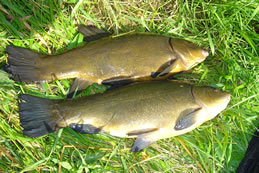

In [75]:
opened_file

In [76]:
opened_file.size

(259, 173)

(259, 173)


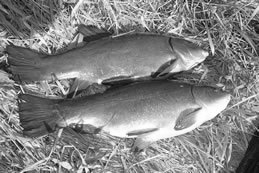

In [69]:
opened_file = opened_file.convert('L') # grayscale
print(opened_file.size)
opened_file

In [70]:
if opened_file.size != (256, 144):
    opened_file = opened_file.resize((256,144))
opened_file.size

(256, 144)

In [71]:
opened_file = np.array(opened_file)
opened_file.shape

(144, 256)

In [72]:
opened_file_stack = np.stack([opened_file]*15, axis = 0)
opened_file_stack.shape

(15, 144, 256)

#### imagenet - predictions

In [9]:
# for now assign to x random images
def random_images(num, train = True, path = os.path.join("//imagenet-mini")):
    """
    NOTE: directory structure for subfolers as follows
    --imagenet-mini
        -->train
            -->folder1
                -->picture1-1
                -->picture2-1.....
            -->folder2...
            -->folder3...
                -->picture1-3
                -->pictuer2-3
                -->picture....
        -->validation


    Parameters
    ----------
    num: int
        number of images 
    frames: int
        number of frames
    train: bool
        using training or validation set, defaults to train
    path: string
        defaults to cwd for training folder, otherwise path to train/val. folders needed

    Returns
    -------
    folder_id
        folder # used
    image_ids
        image #'s used
    np.stack(final_array)
        stack of num DIFFERENT images in one object, shape (num, 144, 256)
    """

    if train == True: train_val = '//train' 
    else: train_val = '//val'

    folder_path = path + train_val # get path to train/val folders
    initial_folders = os.listdir(folder_path)

    folder_id = np.random.randint(0, len(initial_folders) - 1) # get path to random folder within train/val
    image_folder_path = folder_path + '//' + initial_folders[folder_id]

    image_folder = os.listdir(image_folder_path) # path to folder in train/val with images

    image_ids = np.random.randint(0,len(image_folder) - 1, size = num)
    final_array = np.empty(shape = (num, 144, 256))

    for i in range(num):
        image_name = '//' + image_folder[i]
        image_path = image_folder_path + image_name
        image = Image.open(image_path)
        image = image.convert('L')
        if image.size != (256, 144): image = image.resize((256, 144))
        image = np.array(image)
        final_array[i] = image

    return folder_id, image_ids, np.stack(final_array, axis = 0)


In [31]:
folder_id, image_ids, image_stack = random_images(5, path = "C://Users//joshf//Downloads//imagenet-mini")

#### predicting on five random images from previous section

In [143]:
def predict_loop(noise_type, noise_seeds, images, sigma, scans, num_frames = 30): 
    """
    Parameters
    ----------
    noise_type: string
        dynamic, constant, or no noise NOTE: make stochastic binarization a parameter here
    noise_seeds: int
        how many times we add noise to the prediction
    images: object
        images (usually object from np.stack()) that we are adding noise to and then predicting on
    sigma: int
        standard deviation for gaussian noise distribution
    scans: list/array
        should be 2d array with pairs of sessions and scan ids taken from scans.csv
    num_frames: int
        number of frames per image, defaults to 30
    
    Returns
    -------
    stack_sum
        array with predictions for each image, noise_seed, and neuron
    mean_array
        returns array with each mean neuron prediction for all images entered
    var_array
        returns array with each var. in neuron prediction for all images entered
        
    ex. input predict_loop("constant", 100, image, 3, [[4,6], [5,7]])
    """
    final_array = np.empty(shape = (len(images), noise_seeds, num_frames, get_neuron_units(scans)))

    for i, element in enumerate(images):
        predict_stack = np.stack([images[i]] * num_frames, axis = 0)

        prediction1 = inner_predict_loop(noise_type, noise_seeds, predict_stack, sigma, scans)  # shape is (noise_seeds, frames, neurons)

        try:
            if (prediction_stack.shape != prediction1.shape): 
                prediction1 = np.reshape(prediction1, (1, prediction1.shape[0], prediction1.shape[1], prediction1.shape[2]))
                prediction_stack = np.stack((prediction1, prediction_stack), axis = 0)
        except NameError:
            prediction_stack = prediction1
        
        final_array[i] = prediction_stack
        del prediction_stack

    #final_stack = np.stack(final_array, axis = 0)
    final_stack_sum = np.sum(final_array, axis = 2)

    return final_stack_sum, np.mean(final_stack_sum, axis = 1), np.var(final_stack_sum, axis = 1)
            

In [98]:
# note: we are using 10 noise seeds here and 5 frames of each image

# dynamic
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 10, image_stack, 3, [[4,7]], num_frames = 5)
dynamic15, dynamic15_mean, dynamic15_var = predict_loop("dynamic", 10, image_stack, 15, [[4,7]], num_frames = 5)
dynamic30, dynamic30_mean, dynamic30_var = predict_loop("dynamic", 10, image_stack, 30, [[4,7]], num_frames = 5)

# constant
constant3, constant3_mean, constant3_var = predict_loop("constant", 10, image_stack, 3, [[4,7]], num_frames = 5)
constant15, constant15_mean, constant15_var = predict_loop("constant", 10, image_stack, 15, [[4,7]], num_frames = 5)
constant30, constant30_mean, constant30_var = predict_loop("constant", 10, image_stack, 30, [[4,7]], num_frames = 5)

In [144]:
dynamic3, dynamic3_mean, dynamic3_var = predict_loop("dynamic", 10, image_stack, 3, [[4,7]], num_frames = 5)


##### visualizations 

In [145]:
neurons = np.random.randint(0, np.max(7493), size = 30)
print('random neurons: ', neurons)

random neurons:  [ 733  926 3107 4716 1704 3987 1076 2451  734 5002  460 3260 2672 2863
 6129  346 3174 5632 4541 5623 1949 7226 7328 7116 7360 1540 5784 4664
 6317 3463]


In [146]:
dynamic3.shape

(5, 10, 7493)

In [153]:
len(dynamic3.flatten())

374650

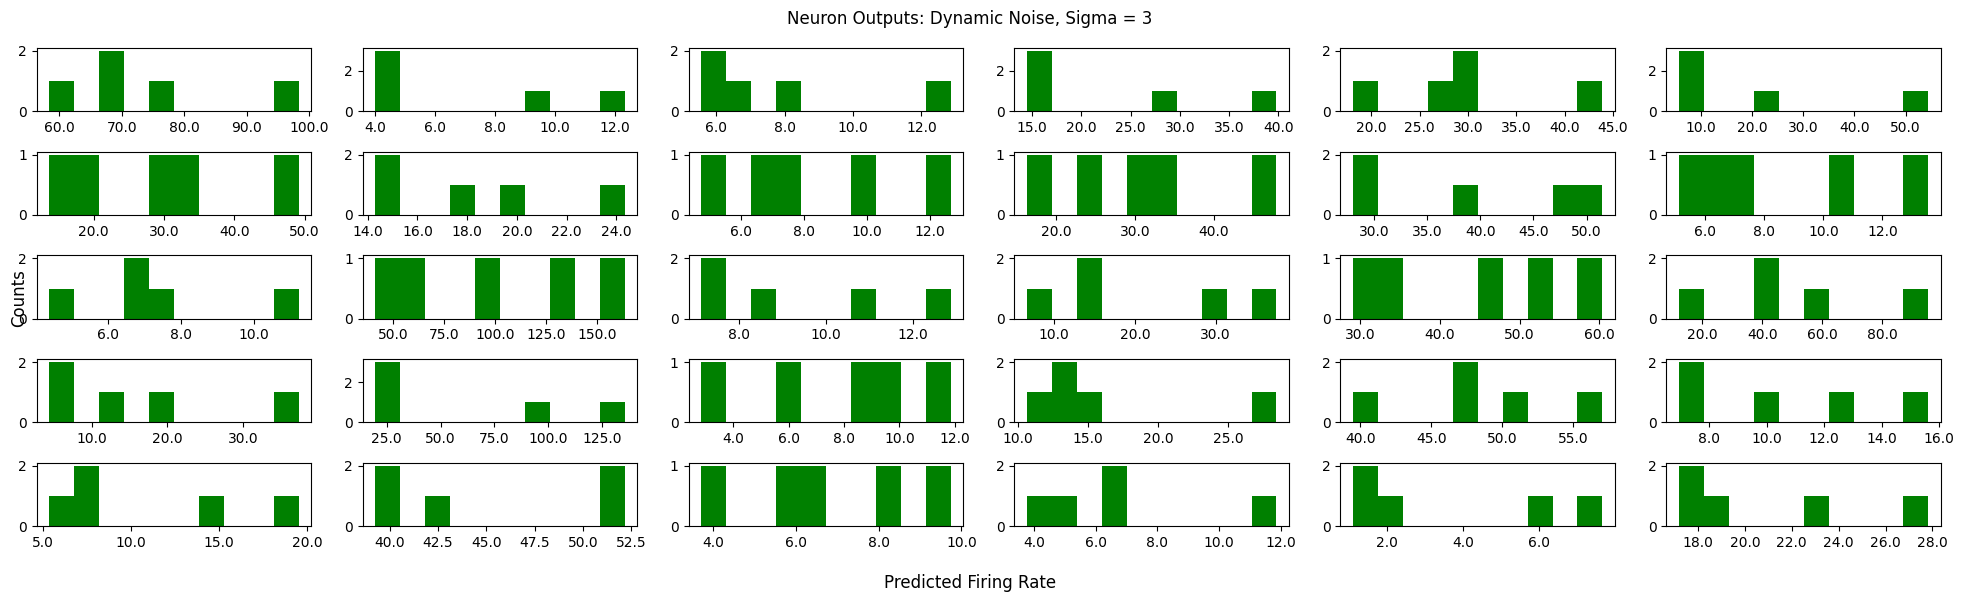

    neuron  p_value
0      733    0.898
1      926    0.815
2     3107    0.784
3     4716    0.787
4     1704    0.899
5     3987    0.747
6     1076    0.951
7     2451    0.933
8      734    0.970
9     5002    0.961
10     460    0.905
11    3260    0.911
12    2672    0.894
13    2863    0.967
14    6129    0.920
15     346    0.923
16    3174    0.953
17    5632    0.961
18    4541    0.882
19    5623    0.815
20    1949    0.975
21    7226    0.742
22    7328    0.978
23    7116    0.908
24    7360    0.884
25    1540    0.806
26    5784    0.964
27    4664    0.853
28    6317    0.828
29    3463    0.848


In [152]:
plot_select30_hist(dynamic3, "Dynamic Noise, Sigma = 3", neurons)

In [142]:
dynamic3.shape

(5, 10, 7493)